# Type C — Instant Funded Account Insurance

**What you're doing:** Pay a premium fee upfront, get funded immediately (no challenge phases), and hedge while earning the first payout.

**How it differs from challenge-based Types A, B, C:**
- No challenge phases to pass — you skip straight to funded
- The fee is much higher than a normal challenge (it's the price of skipping)
- You start hedging from day one of the funded account

**Why cross-firm pairing is impractical for instant funded:**
- Premium fees are too high to double (you'd need 2x the premium at different firms)
- The cost makes the EV equation much worse than challenge-based hedging
- **Personal hedge is the primary method** — your own brokerage hedges the single funded account

## The Numbers

$$\text{Total Cost} = \text{Fee} + \text{Activation Fee} + \text{Hedge Losses while earning payout}$$

$$\text{Funded Payout} = \text{Account Size} \times \text{Payout Target \%} \times \text{Profit Split \%}$$

$$\text{EV} = \text{Funded Payout} - \text{Total Cost}$$

> For static DD: the hedge cost is a single-stage calculation.
> For trailing DD: costs compound daily, same as the challenge-based trailing model.

## Important

- **Personal hedge method only** — cross-firm pairing at 2x premium fee is almost never EV+
- Both static and EOD trailing drawdown variants exist
- Intra-day trailing DD is NOT hedgeable (floor moves within the trading day)

## Setup

In [1]:
import sqlite3, json, os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DB_PATH = os.path.join(
    os.environ.get("WORKSPACE_ROOT", r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"),
    "Business", "STRATEGY", "resources", "PropFirmData", "propmatch_model_input.db"
)

# ── Assumptions ──
PAYOUT_TARGET = 0.08   # 8% funded target
SPREAD_COST   = 0.0003
LEVERAGE      = 100
DEFAULT_TRADING_DAYS = 5  # if min_trading_days not specified

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print(f"Type C notebook ready.")
print(f"Payout target: {PAYOUT_TARGET*100:.0f}%  |  Spread: {SPREAD_COST*100:.2f}%  |  Leverage: 1:{LEVERAGE}")

Type C notebook ready.
Payout target: 8%  |  Spread: 0.03%  |  Leverage: 1:100


## Load Instant Funded Offers

In [2]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("SELECT * FROM v_model_inputs WHERE survival_model_class IN ('instant_static', 'instant_trailing') ORDER BY account_size, fee_assumed").fetchall()
conn.close()

challenges = []
for row in rows:
    d = dict(row)
    pt = d.pop("profit_targets", None)
    if isinstance(pt, str):
        try:
            d["profit_targets"] = json.loads(pt)
        except (json.JSONDecodeError, TypeError):
            d["profit_targets"] = []
    else:
        d["profit_targets"] = pt or []
    challenges.append(d)

df_raw = pd.DataFrame(challenges)
print(f"Loaded {len(challenges)} instant-funded offers")
print(f"Firms: {df_raw['firm'].nunique()}")
print(f"\nDrawdown breakdown:")
print(f"  Static (balance-based): {(df_raw['survival_model_class']=='instant_static').sum()}")
print(f"  Trailing (EOD):         {(df_raw['survival_model_class']=='instant_trailing').sum()}")
print(f"\nAccount sizes: {sorted(df_raw['account_size'].unique())}")

Loaded 167 instant-funded offers
Firms: 18

Drawdown breakdown:
  Static (balance-based): 55
  Trailing (EOD):         112

Account sizes: [np.int64(625), np.int64(1000), np.int64(1250), np.int64(2000), np.int64(2500), np.int64(3000), np.int64(5000), np.int64(6000), np.int64(7500), np.int64(10000), np.int64(15000), np.int64(20000), np.int64(25000), np.int64(40000), np.int64(50000), np.int64(60000), np.int64(75000), np.int64(80000), np.int64(100000), np.int64(120000), np.int64(150000), np.int64(200000), np.int64(300000), np.int64(400000)]


## Type C Math Engine

Instant funded has **no challenge phases** — you go straight to funded trading.

**For static drawdown:**
- One hedge cycle: size the hedge, earn the target, pay spread
- Cost = fee + hedge loss from earning the payout target
- Hedge size = cost so far ÷ DD%

**For trailing drawdown (EOD):**
- Same daily compounding as Type B
- Daily target = payout target ÷ trading days
- Each day the floor rises, the hedge grows

**Trading days:** Uses min_trading_days from the offer, or defaults to 5 if not specified.

In [3]:
def compute_type_c(challenge, payout_target=PAYOUT_TARGET, spread_cost=SPREAD_COST):
    S = challenge['account_size']
    fee = challenge.get('fee_assumed') or challenge.get('fee_discounted') or 0
    activation_fee = challenge.get('activation_fee') or 0
    dd_pct = (challenge.get('max_drawdown_pct') or 10) / 100
    split = (challenge.get('profit_split_pct') or 80) / 100
    min_days = int(challenge.get('min_trading_days') or DEFAULT_TRADING_DAYS)
    min_days = max(min_days, 1)
    model_class = challenge.get('survival_model_class', 'instant_static')
    is_trailing = 'trailing' in model_class

    # Start with fee + activation (both paid upfront for instant)
    L = float(fee) + float(activation_fee)
    daily_target = payout_target / min_days

    daily_log = []

    if is_trailing:
        # Trailing: daily compounding (same math as Type B)
        for day in range(min_days):
            hedge_size = L / dd_pct if dd_pct > 0 else 0
            daily_loss = hedge_size * daily_target
            spread_day = hedge_size * spread_cost * 2
            L += daily_loss + spread_day
            daily_log.append({
                'day': day + 1, 'hedge_size': round(hedge_size, 2),
                'daily_loss': round(daily_loss, 2), 'spread': round(spread_day, 2),
                'cost_after': round(L, 2),
            })
    else:
        # Static: one-shot hedge (days only affect spread count)
        hedge_size = L / dd_pct if dd_pct > 0 else 0
        spread_total = hedge_size * spread_cost * 2 * min_days
        hedge_loss = hedge_size * payout_target + spread_total
        L += hedge_loss
        daily_log.append({
            'day': min_days, 'hedge_size': round(hedge_size, 2),
            'daily_loss': round(hedge_loss, 2), 'spread': round(spread_total, 2),
            'cost_after': round(L, 2),
        })

    total_cost = L
    funded_payout = S * payout_target * split
    EV = funded_payout - total_cost
    final_hedge = L / dd_pct if dd_pct > 0 else 0
    margin = final_hedge / LEVERAGE
    buffer = final_hedge * dd_pct * 1.5
    cap = margin + buffer

    return {
        'firm': challenge.get('firm'), 'account_size': S,
        'fee': round(fee, 2), 'activation_fee': round(activation_fee, 2),
        'dd_type': 'trailing' if is_trailing else 'static',
        'max_drawdown_pct': round(dd_pct * 100, 2),
        'profit_split_pct': round(split * 100, 1),
        'min_trading_days': min_days,
        'daily_target_pct': round(daily_target * 100, 4),
        'daily_log': daily_log,
        'total_cost': round(total_cost, 2), 'funded_payout': round(funded_payout, 2),
        'EV': round(EV, 2),
        'breakeven_pct': round((total_cost / split / S) * 100, 2) if S > 0 else 0,
        'capital_needed': round(cap, 2),
        'capital_efficiency': round(EV / cap, 4) if cap > 0 else 0,
    }

results = [compute_type_c(c) for c in challenges]
df = pd.DataFrame(results)

pos = (df['EV'] > 0).sum()
print(f"Positive EV: {pos}/{len(df)} offers")
print(f"Average EV:  ${df['EV'].mean():,.2f}")
if pos > 0:
    best = df.loc[df['EV'].idxmax()]
    print(f"Best EV:     {best['firm']} ${best['account_size']:,.0f} [{best['dd_type']}] → ${best['EV']:,.2f}")
print(f"\nBy drawdown type:")
for dd in df['dd_type'].unique():
    mask = df['dd_type'] == dd
    print(f"  {dd}: {mask.sum()} offers, {(df.loc[mask, 'EV'] > 0).sum()} positive EV, avg EV ${df.loc[mask, 'EV'].mean():,.2f}")

Positive EV: 76/167 offers
Average EV:  $1,039.16
Best EV:     AquaFunded $400,000 [static] → $22,367.38

By drawdown type:
  trailing: 112 offers, 46 positive EV, avg EV $686.49
  static: 55 offers, 30 positive EV, avg EV $1,757.31


## Type C Rankings — Top 30

In [4]:
rank_cols = ['firm', 'account_size', 'fee', 'activation_fee', 'dd_type',
             'max_drawdown_pct', 'profit_split_pct', 'min_trading_days',
             'total_cost', 'funded_payout', 'EV', 'breakeven_pct',
             'capital_needed', 'capital_efficiency']

df.sort_values('EV', ascending=False)[rank_cols].head(30).style.format({
    'fee': '${:,.0f}', 'activation_fee': '${:,.0f}',
    'total_cost': '${:,.2f}', 'funded_payout': '${:,.2f}', 'EV': '${:,.2f}',
    'breakeven_pct': '{:.1f}%', 'capital_needed': '${:,.0f}',
    'capital_efficiency': '{:.4f}', 'max_drawdown_pct': '{:.1f}%',
    'profit_split_pct': '{:.0f}%', 'account_size': '${:,}',
}).bar(subset=['EV'], color='#5fba7d').set_caption(
    f'Type C: Instant Funded Insurance — Top 30 (payout target: {PAYOUT_TARGET*100:.0f}%)')

,firm,account_size,fee,activation_fee,dd_type,max_drawdown_pct,profit_split_pct,min_trading_days,total_cost,funded_payout,EV,breakeven_pct,capital_needed,capital_efficiency
165,AquaFunded,"$400,000","$2,699",$0,static,6.0%,90%,5,"$6,432.62","$28,800.00","$22,367.38",1.8%,"$10,721",2.0863
164,AquaFunded,"$400,000","$2,699",$0,trailing,6.0%,90%,5,"$9,153.57","$28,800.00","$19,646.43",2.5%,"$15,256",1.2878
162,AquaFunded,"$300,000","$2,099",$0,static,6.0%,90%,5,"$5,002.62","$21,600.00","$16,597.38",1.9%,"$8,338",1.9906
166,Blue Guardian,"$400,000","$2,752",$0,trailing,6.0%,80%,5,"$9,333.32","$25,600.00","$16,266.68",2.9%,"$15,556",1.0457
160,Instant Funding,"$300,000","$1,659",$0,static,6.0%,80%,5,"$3,953.95","$19,200.00","$15,246.05",1.6%,"$6,590",2.3135
161,AquaFunded,"$300,000","$2,099",$0,trailing,6.0%,90%,5,"$7,118.69","$21,600.00","$14,481.31",2.6%,"$11,864",1.2206
163,Blue Guardian,"$300,000","$2,140",$0,trailing,6.0%,80%,5,"$7,257.74","$19,200.00","$11,942.26",3.0%,"$12,096",0.9873
153,Instant Funding,"$200,000",$939,$0,static,4.0%,90%,5,"$2,887.43","$14,400.00","$11,512.58",1.6%,"$5,053",2.2784
156,AquaFunded,"$200,000","$1,250",$0,trailing,6.0%,90%,5,"$4,239.33","$14,400.00","$10,160.67",2.4%,"$7,066",1.4381
155,Instant Funding,"$200,000","$1,199",$0,static,6.0%,80%,5,"$2,857.62","$12,800.00","$9,942.38",1.8%,"$4,763",2.0876


## EV Chart — Best and Worst Offers

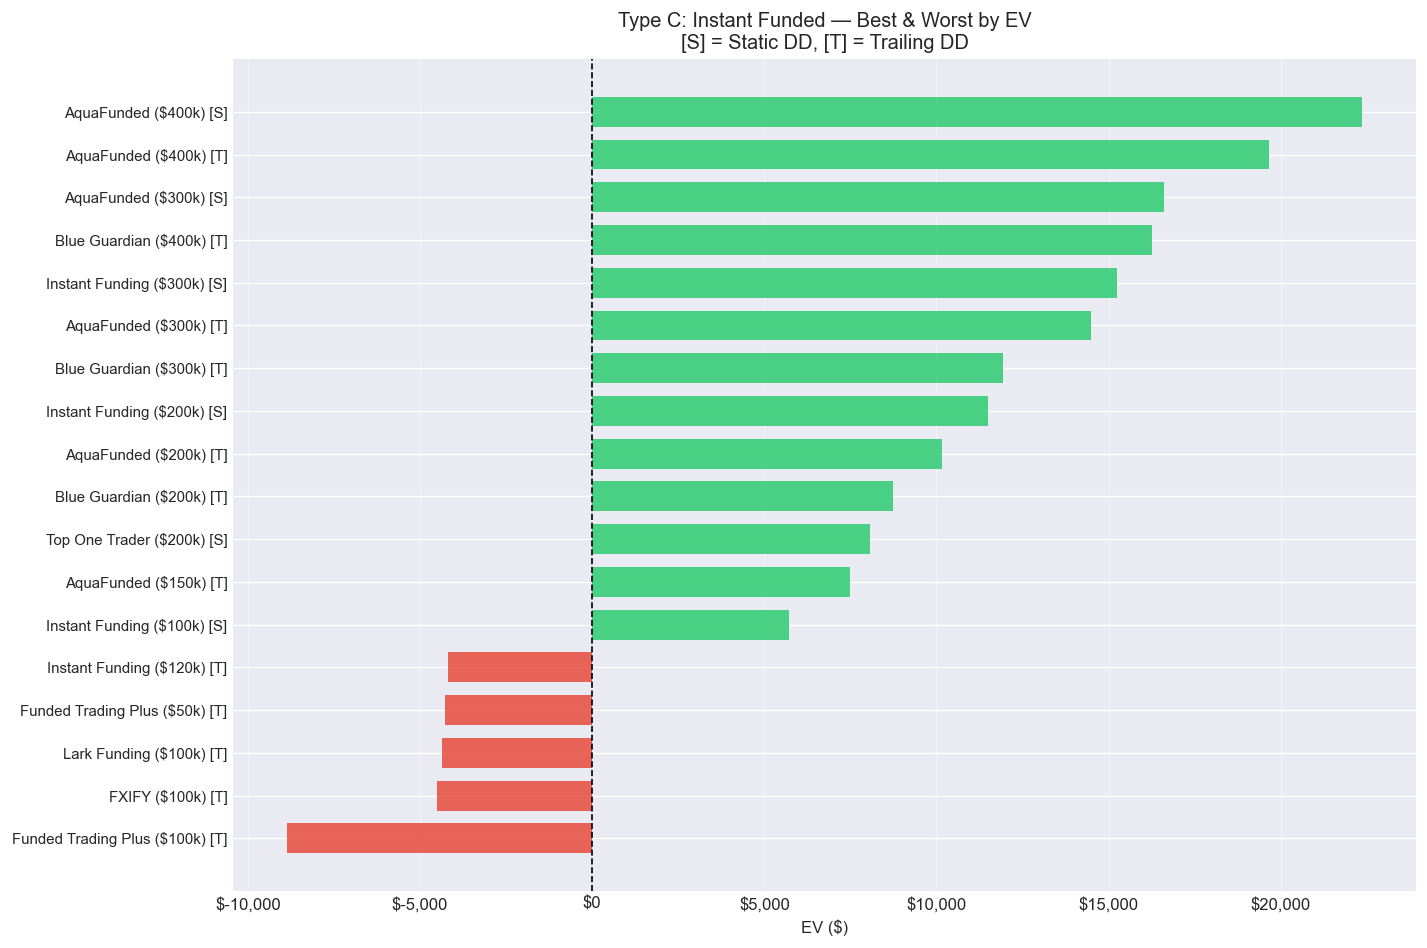

In [5]:
df_sorted = df.sort_values('EV', ascending=False)
df_show = pd.concat([df_sorted.head(15), df_sorted.tail(5)]).drop_duplicates(
    subset=['firm', 'account_size', 'dd_type']).sort_values('EV', ascending=True).copy()
df_show['label'] = df_show.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k) [{r['dd_type'][0].upper()}]", axis=1)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_show['EV']]
ax.barh(range(len(df_show)), df_show['EV'], color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(df_show)))
ax.set_yticklabels(df_show['label'], fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('EV ($)')
ax.set_title('Type C: Instant Funded — Best & Worst by EV\n[S] = Static DD, [T] = Trailing DD')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Static vs Trailing Comparison

Same concept as Type A vs Type B — static DD keeps costs linear, trailing compounds them.

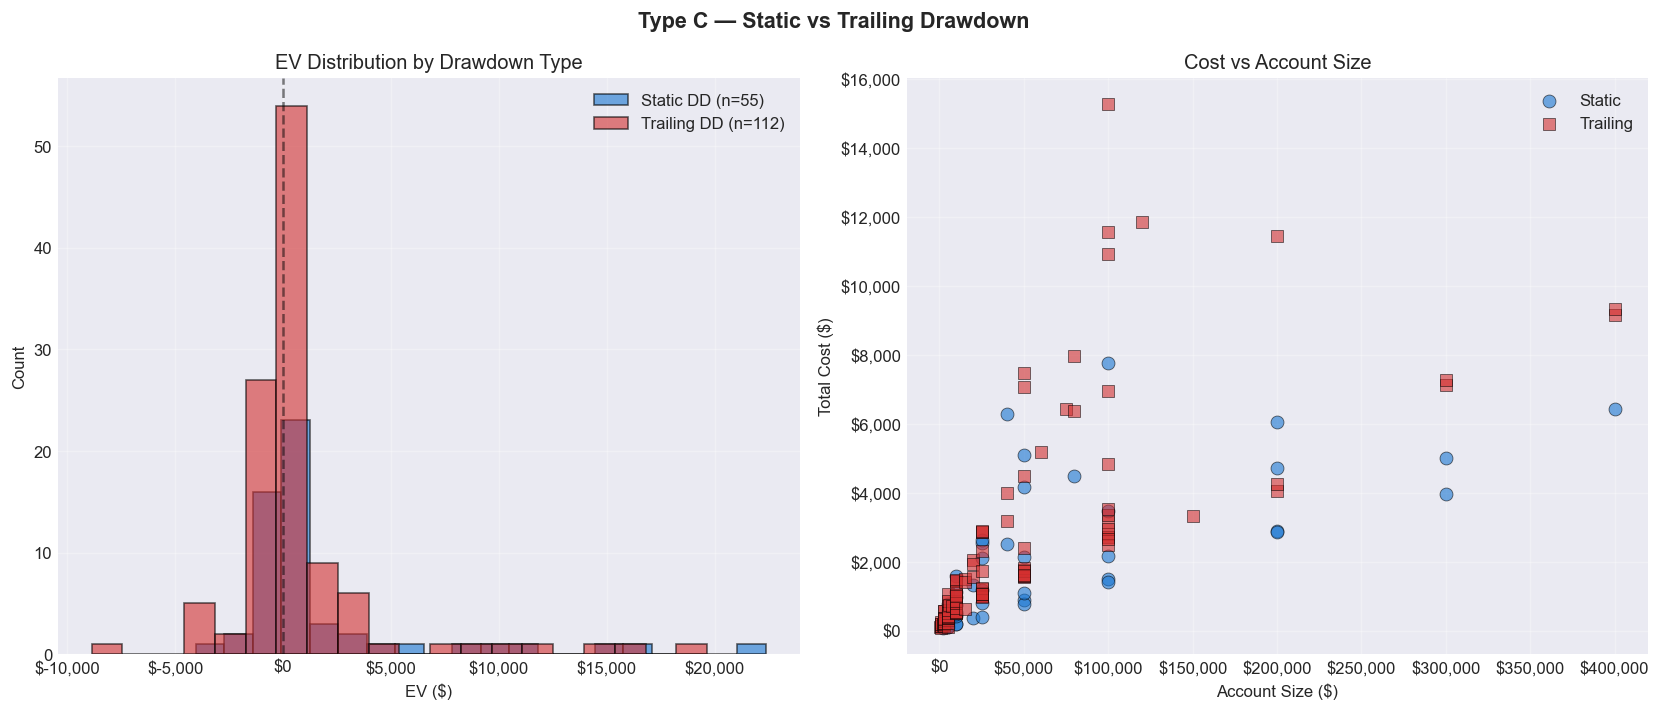

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: EV distribution by DD type
for dd, color, lbl in [('static', '#1976d2', 'Static DD'), ('trailing', '#d32f2f', 'Trailing DD')]:
    mask = df['dd_type'] == dd
    if mask.any():
        ax1.hist(df.loc[mask, 'EV'], bins=20, alpha=0.6, color=color,
                 label=f'{lbl} (n={mask.sum()})', edgecolor='black')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('EV ($)')
ax1.set_ylabel('Count')
ax1.set_title('EV Distribution by Drawdown Type')
ax1.legend()
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: cost vs account size by DD type
for dd, marker, color, lbl in [('static', 'o', '#1976d2', 'Static'), ('trailing', 's', '#d32f2f', 'Trailing')]:
    mask = df['dd_type'] == dd
    if mask.any():
        ax2.scatter(df.loc[mask, 'account_size'], df.loc[mask, 'total_cost'],
                    marker=marker, color=color, alpha=0.6, s=60, label=lbl, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Account Size ($)')
ax2.set_ylabel('Total Cost ($)')
ax2.set_title('Cost vs Account Size')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Type C — Static vs Trailing Drawdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Payout Target Sensitivity

How does EV change with different payout targets?

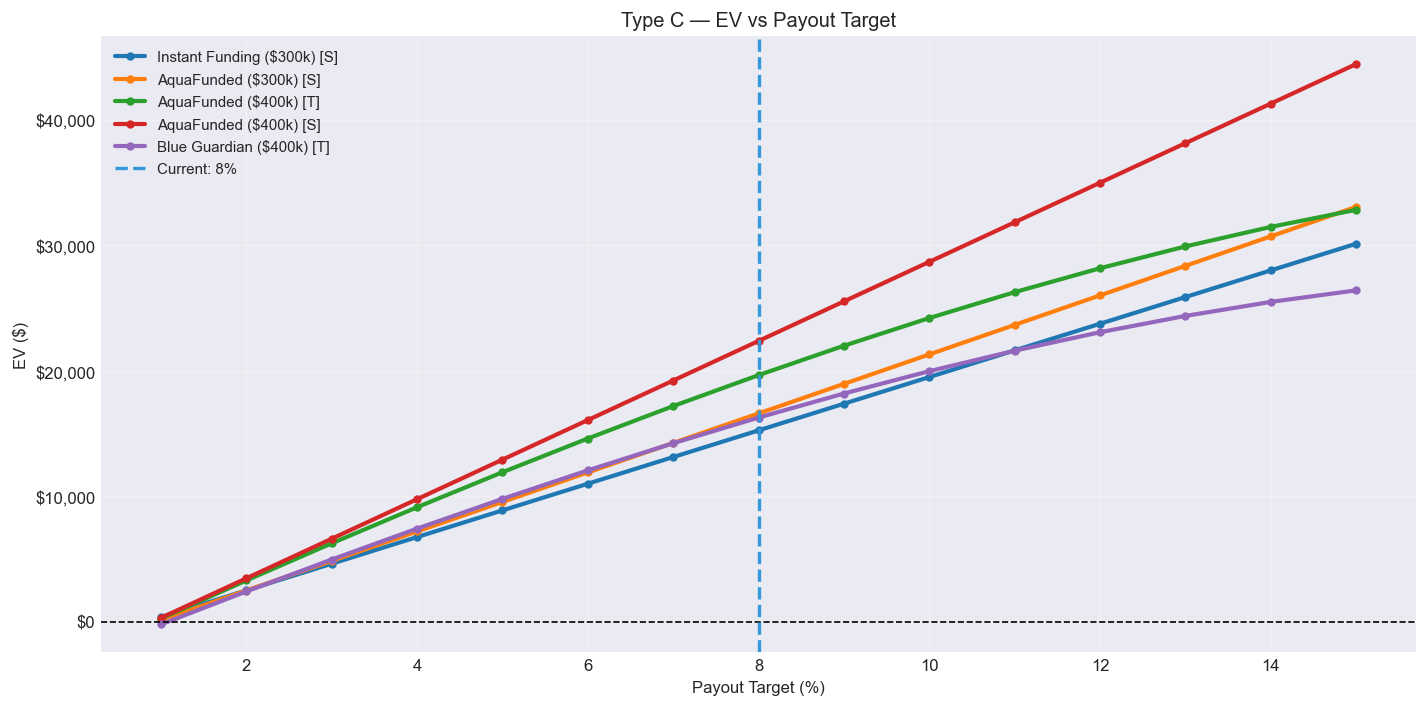

In [7]:
top5 = df.nlargest(5, 'EV')
top5_keys = set(zip(top5['firm'], top5['account_size'], top5['dd_type']))
top5_chs = [c for c in challenges if (
    c.get('firm'), c.get('account_size'),
    'trailing' if 'trailing' in (c.get('survival_model_class') or '') else 'static'
) in top5_keys]

fig, ax = plt.subplots(figsize=(12, 6))
sweep = [p / 100 for p in range(1, 16)]
cm = plt.cm.tab10.colors

for i, ch in enumerate(top5_chs[:5]):
    dd = 'T' if 'trailing' in (ch.get('survival_model_class') or '') else 'S'
    evs = [compute_type_c(ch, payout_target=t)['EV'] for t in sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k) [{dd}]"
    ax.plot([t * 100 for t in sweep], evs, marker='o', markersize=4,
            linewidth=2.5, color=cm[i % 10], label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(PAYOUT_TARGET * 100, color='#3498db', linestyle='--', linewidth=2,
           label=f'Current: {PAYOUT_TARGET*100:.0f}%')
ax.set_xlabel('Payout Target (%)')
ax.set_ylabel('EV ($)')
ax.set_title('Type C — EV vs Payout Target')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Capital Efficiency

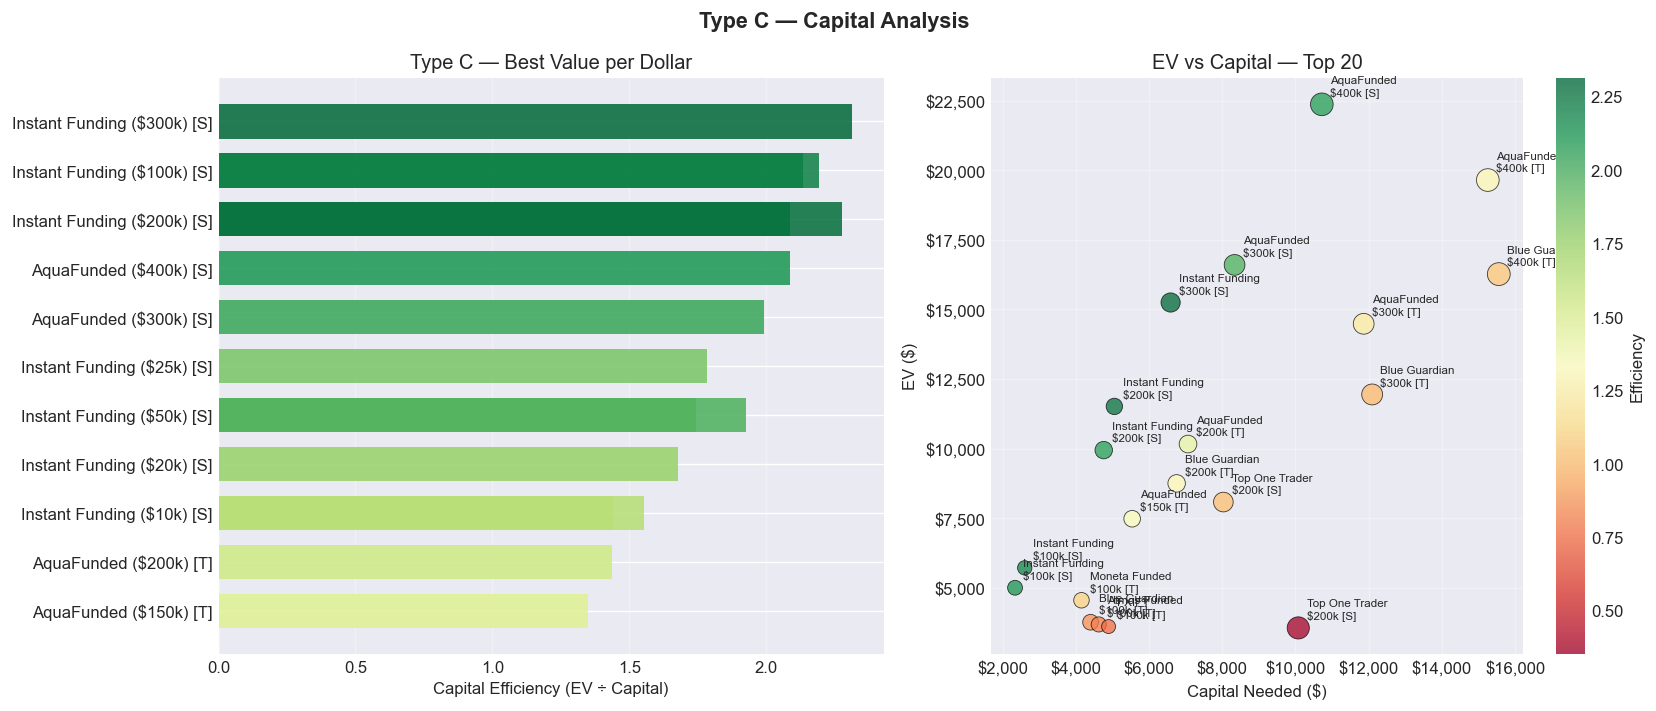

In [8]:
df_cap = df[df['capital_efficiency'] > 0].nlargest(15, 'capital_efficiency').sort_values(
    'capital_efficiency', ascending=True).copy()
df_cap['label'] = df_cap.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k) [{r['dd_type'][0].upper()}]", axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.RdYlGn([v / df_cap['capital_efficiency'].max() for v in df_cap['capital_efficiency']])
ax1.barh(df_cap['label'], df_cap['capital_efficiency'], color=cmap, alpha=0.85, height=0.7)
ax1.set_xlabel('Capital Efficiency (EV ÷ Capital)')
ax1.set_title('Type C — Best Value per Dollar')
ax1.grid(axis='x', alpha=0.3)

top20 = df.nlargest(20, 'EV')
sc = ax2.scatter(top20['capital_needed'], top20['EV'], s=top20['fee'] * 0.05 + 50, alpha=0.75,
                 c=top20['capital_efficiency'], cmap='RdYlGn', edgecolors='black', linewidth=0.5)
for _, r in top20.iterrows():
    ax2.annotate(f"{r['firm']}\n${r['account_size']/1000:.0f}k [{r['dd_type'][0].upper()}]",
                 (r['capital_needed'], r['EV']), textcoords='offset points', xytext=(5, 5), fontsize=7)
ax2.set_xlabel('Capital Needed ($)')
ax2.set_ylabel('EV ($)')
ax2.set_title('EV vs Capital — Top 20')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)
plt.colorbar(sc, ax=ax2, label='Efficiency')
plt.suptitle('Type C — Capital Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Scratch check: FundingPips instant-funded rows
fp = df_raw[df_raw['firm'].str.contains('FundingPips', case=False, na=False)].copy()
show_cols = [c for c in [
    'firm', 'program_name', 'account_size', 'fee_assumed', 'activation_fee',
    'survival_model_class', 'drawdown_type', 'hedgeable', 'hedgeability_reason',
    'max_drawdown_pct', 'profit_split_pct', 'min_trading_days', 'payout_timing', 'steps_label'
] if c in fp.columns]
print(fp[show_cols].to_string(index=False))

Empty DataFrame
Columns: [firm, program_name, account_size, fee_assumed, activation_fee, survival_model_class, drawdown_type, hedgeable, hedgeability_reason, max_drawdown_pct, profit_split_pct, min_trading_days, payout_timing, steps_label]
Index: []


In [6]:
# Personalized: instant-funded hedge now for an existing FundingPips 30k account
TARGET_FIRM = 'FundingPips'
TARGET_SIZE = 30_000
FEE_CAP = 500
SIZE_RATIO_CAP = 2.5

raw_keep = ['program_name', 'hedgeable', 'hedgeability_reason', 'payout_timing', 'drawdown_type']
raw_keep = [c for c in raw_keep if c in df_raw.columns]
raw_side = df_raw[raw_keep].reset_index(drop=True).copy()
raw_side = raw_side.rename(columns={c: f'raw_{c}' for c in raw_side.columns})

df_inst = pd.concat([
    df.reset_index(drop=True),
    raw_side
], axis=1)

df_inst['upfront_fee'] = df_inst['fee'].fillna(0)
df_inst['offer_min_days'] = df_inst['min_trading_days'].fillna(DEFAULT_TRADING_DAYS)
df_inst['size_ratio'] = df_inst['account_size'].apply(
    lambda s: max(s, TARGET_SIZE) / min(s, TARGET_SIZE)
)
df_inst['size_gap'] = (df_inst['account_size'] - TARGET_SIZE).abs()
df_inst['static_pref'] = (df_inst['dd_type'] == 'static').astype(int)

hedgeable_mask = df_inst['raw_hedgeable'] == 1 if 'raw_hedgeable' in df_inst.columns else True
eligible = df_inst[
    hedgeable_mask &
    (df_inst['firm'] != TARGET_FIRM) &
    (df_inst['account_size'].between(TARGET_SIZE / SIZE_RATIO_CAP, TARGET_SIZE * SIZE_RATIO_CAP))
].copy()

eligible = eligible.sort_values(
    ['static_pref', 'offer_min_days', 'size_gap', 'EV', 'upfront_fee'],
    ascending=[False, True, True, False, True]
).reset_index(drop=True)

under_cap = eligible[eligible['upfront_fee'] <= FEE_CAP].copy()
under_cap = under_cap.sort_values(
    ['static_pref', 'offer_min_days', 'size_gap', 'EV', 'upfront_fee'],
    ascending=[False, True, True, False, True]
).reset_index(drop=True)

best_now = eligible.iloc[0] if not eligible.empty else None
best_now_cap = under_cap.iloc[0] if not under_cap.empty else None
best_value_cap = under_cap.sort_values(
    ['EV', 'static_pref', 'size_gap', 'upfront_fee'],
    ascending=[False, False, True, True]
).iloc[0] if not under_cap.empty else None

print(f'Instant-funded hedge-now screen for existing {TARGET_FIRM} ${TARGET_SIZE:,.0f} account')
print(f'Eligible offers: {len(eligible)} | Under ${FEE_CAP}: {len(under_cap)}\n')

if best_now is not None:
    print('Best immediate hedge now (no fee cap):')
    print(
        f"  {best_now['firm']} ${best_now['account_size']:,.0f} [{best_now['dd_type']}] | "
        f"fee=${best_now['upfront_fee']:,.0f} | min_days={int(best_now['offer_min_days'])} | "
        f"EV=${best_now['EV']:,.0f} | capital=${best_now['capital_needed']:,.0f} | "
        f"size_ratio={best_now['size_ratio']:.2f}x"
    )
    if 'raw_payout_timing' in best_now.index:
        print(f"  payout timing: {best_now['raw_payout_timing']}")

if best_now_cap is not None:
    print('\nBest immediate hedge now under fee cap:')
    print(
        f"  {best_now_cap['firm']} ${best_now_cap['account_size']:,.0f} [{best_now_cap['dd_type']}] | "
        f"fee=${best_now_cap['upfront_fee']:,.0f} | min_days={int(best_now_cap['offer_min_days'])} | "
        f"EV=${best_now_cap['EV']:,.0f} | capital=${best_now_cap['capital_needed']:,.0f} | "
        f"size_ratio={best_now_cap['size_ratio']:.2f}x"
    )

if best_value_cap is not None:
    print('\nBest value under fee cap (EV-first):')
    print(
        f"  {best_value_cap['firm']} ${best_value_cap['account_size']:,.0f} [{best_value_cap['dd_type']}] | "
        f"fee=${best_value_cap['upfront_fee']:,.0f} | min_days={int(best_value_cap['offer_min_days'])} | "
        f"EV=${best_value_cap['EV']:,.0f} | capital=${best_value_cap['capital_needed']:,.0f} | "
        f"size_ratio={best_value_cap['size_ratio']:.2f}x"
    )

cols = [
    'firm', 'account_size', 'dd_type', 'upfront_fee', 'offer_min_days',
    'EV', 'capital_needed', 'size_ratio', 'raw_payout_timing'
]
cols = [c for c in cols if c in under_cap.columns]

print('\nTop 10 hedge-now candidates under cap:')
print(under_cap[cols].head(10).to_string(index=False))

Instant-funded hedge-now screen for existing FundingPips $30,000 account
Eligible offers: 51 | Under $500: 27

Best immediate hedge now (no fee cap):
  Instant Funding $25,000 [static] | fee=$169 | min_days=5 | EV=$1,197 | capital=$671 | size_ratio=1.20x
  payout timing: Payout-On-Demand

Best immediate hedge now under fee cap:
  Instant Funding $25,000 [static] | fee=$169 | min_days=5 | EV=$1,197 | capital=$671 | size_ratio=1.20x

Best value under fee cap (EV-first):
  Instant Funding $50,000 [static] | fee=$289 | min_days=5 | EV=$2,711 | capital=$1,555 | size_ratio=1.67x

Top 10 hedge-now candidates under cap:
            firm  account_size  dd_type  upfront_fee  offer_min_days      EV  capital_needed  size_ratio                    raw_payout_timing
 Instant Funding         25000   static        169.0               5 1197.22          671.31    1.200000                     Payout-On-Demand
  Top One Trader         25000   static        296.0               5  812.64         1338.51    

## Summary

### What instant funded hedging means for you

- **Skip the challenge, start funded.** You pay a premium fee for instant access.
- The fee IS the main cost — there's no multi-phase cost compounding like Types A & B
- You still need to hedge while earning the payout target (personal hedge method)
- Static DD offers are cheaper to hedge than trailing DD offers

### Why personal hedge only

Cross-firm pairing requires buying TWO instant funded accounts at different firms.
With premium fees typically 3-5x higher than challenge fees, doubling that cost
almost always kills the EV. **Stick to personal hedge for instant funded.**

### Key differences from challenge-based hedging

- No challenge phases = no phase-to-phase cost stacking
- Higher upfront fee = need larger funded payouts to break even
- Simpler to execute — just hedge the funded account from day one
- The compute model is the same as Type A at funded (single payout cycle)

### What's excluded

- **Intra-day trailing drawdown** offers are not hedgeable (the DD floor moves within
  each trading day, making offsetting positions unsafe)
- Futures instant accounts (separate data source needed)